# Understanding Image Classification without Neural Networks

> Explanation of Image classification without use of neural networks and fancy models.

- toc:true
- branch: master
- badges: true
- image : images/3.jpg
- author: Pratik Kumar
- categories: [Image Classification, Image Processing]

## (A) Introduction 
---
This post aims to take the reader through basics of image classification without using fancy terms. To give a intuition of image classification in as simple as possible manner. Most of us start learning about computer vision directly from complex neural networks (Large CNNs like AlexNet, ResNet, VGG). Although, computer vision models are trending but somehow we neglect the area of image processing (also known as Digital Image Processing). Image processing is a subset of computer vision. A computer vision system uses the image processing algorithms in pre-processing or post-processing steps. By properly using image processing techniques and deep learning architectures we can achieve notable results. 

In this article we will be going with very basic image data and model. Then we will see how does the model and data connect to deep learning techinques. Note this post is my attempt to make the reader to understand image classification task, keeping in mind that reader is a beginner. The reader must have following pre-requisites: 
 
 - Understanding of simple mathematical terms (like Matrices, Arrays)
 - Python (Function, modules)

Our task is to classify images into two classes: Horizontal or Vertical. We will have images with horizontal lines or vertical lines, as shown below, 

![](https://github.com/pr2tik1/blog/blob/master/_notebooks/images/joined.jpg?raw=1 "Left Image: Vertical and Right Image: Horizontal")

The problem can be noted as **Binary Image Classification**. "Binary", since two classes. We will not be creating any neural network architecture. The approach is to follow certain image processing operations.

## (B) Importing Libraries
---
We will be using python libraries: OpenCV, Numpy, and Matplolib. OpenCV library is used to handle images, i.e., from reading image and storing it in a variable and more operations. Numpy is used to handle operations associated with arrays. The last library, matplotlib is used for graphing and ploting the images. For more details about these powerful libraries, visit the reference section. 

In [1]:
#Importing libraries
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline 

## (C) Data 
---
Since our objective is to keep things simple as much possible, we are taking 3x3 pixels in size image. The image is now 3 rows and 3 columns of pixels, as shown below figure(1),

![image](https://github.com/pr2tik1/blog/blob/master/_notebooks/images/332.jpg?raw=1)

Now this same image is read as a matrix of intensity values ranging from 0-255. The values close to '0' makes the image pixel to be **white** and that close to '255' makes the image pixel to be **black**. This scale of values of intensities ranging from white to black (0-255) is known as grayscale. When the size of matrix increases and pixel values is made to vary between the range 0-255, we get a black and white image.

Now, when similar matrix is considered to be stacked with two more, one after the another, as shown in figure(2), we get colored images with RGB channels. To know more about the channels follow [here](https://en.wikipedia.org/wiki/Grayscale#Grayscale_as_single_channels_of_multichannel_color_images). The 'create-img.py' script executed below, creates 3x3 images with a vertical line and horizontal line separately.

In [2]:
#Script to create our image dataset 
!python3 create-img.py

## (D) Image Processing: 
---
Now as we are ready with our data, let's start coding! Below are operations ranging from reading, viewing, normalizing and more.

### D.1. Reading to matrices

We now read images into matrics or arrays. These arrays are of size 3x3 and have values in range 0-255. We store them into **vertical** and **horizontal** variables.

In [3]:
vertical = cv2.imread("vertical.jpg", cv2.IMREAD_GRAYSCALE)
horizontal = cv2.imread("horizontal.jpg", cv2.IMREAD_GRAYSCALE)

### D.2. Arrays
Let's have a view of arrays. 

In [4]:
print("Vertical:\n",vertical)
print("Horizontal:\n",horizontal)

Vertical:
 [[  0 255   0]
 [  0 255   0]
 [  0 255   0]]
Horizontal:
 [[  0   0   0]
 [255 255 255]
 [  0   0   0]]


### D.3. Normalization

This is preprocessing of image data before using it. In this the range of the pixel is changed from 0-255 to 0-1. Normalization to keep all data in the same scale. This process is performed to bring a range into one that is more familiar or normal to the senses, hence the term normalization. 

In [5]:
vertical = vertical/255
horizontal = horizontal/255

In [6]:
print("After normalization, Vertical:\n",vertical)
print("After normalization, Horizontal:\n",horizontal)

After normalization, Vertical:
 [[0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]
After normalization, Horizontal:
 [[0. 0. 0.]
 [1. 1. 1.]
 [0. 0. 0.]]


But how does our images of 3x3 size look like?

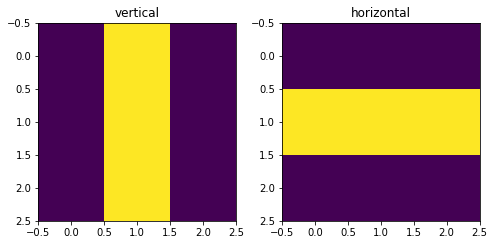

In [16]:
#collapse-hide
figure =plt.figure(figsize=(8., 8.))
plt.rcParams['figure.facecolor'] = 'white'
plt.subplot(221)
plt.imshow(vertical)
plt.gca().set_title('vertical')
plt.subplot(222)
plt.imshow(horizontal)
plt.gca().set_title('horizontal')

plt.show()

### D.4. Flattening

We now flatten the image, i.e., change the 3x3 matrix to 1x9 vectors. Following are the matrices flattened,

In [8]:
#collapse-hide
vertical_flat = vertical.flatten()
horizontal_flat = horizontal.flatten()
print("Vertical Falttened", vertical_flat)
print("Horizontal Falttened",horizontal_flat)

Vertical Falttened [0. 1. 0. 0. 1. 0. 0. 1. 0.]
Horizontal Falttened [0. 0. 0. 1. 1. 1. 0. 0. 0.]


How does the flattened image look like? Foe this we actually increase dimension for plotting as the image of dimension 1x9 is considered 1-D by matplotlib. Hence to make it acceptable by plotting library we increase the dimension to 2-D.

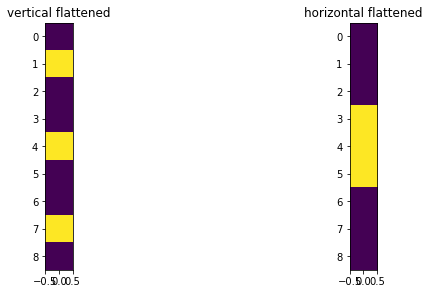

In [9]:
#collapse-hide
#Making the flattened image from 1-D to 2-D for ploltting in matploltib 
vertical_ = np.expand_dims(vertical_flat, axis=1) 
horizontal_ = np.expand_dims(horizontal_flat, axis=1) 

figure = plt.figure(figsize=(10., 10.))
plt.rcParams['figure.facecolor'] = 'white'

plt.subplot(221)
plt.imshow(vertical_)
plt.gca().set_title('vertical flattened')
plt.subplot(222)
plt.imshow(horizontal_)
plt.gca().set_title('horizontal flattened')

plt.show()

## (E) Creating Image Classifier 
---
After above operations like falttening, normalization, we now create our final image classifier as a function below. Note this is not a neural network, which will be discussed later. We also import two test images : test1.jpg and test2.jpg for checking our model. 

To recap, we have seen vertical and horizontal images of 3x3 pixels. Then we changed them into arrays of intensity values. Then we performed normalization and flattening. We now create function that would perform these operations. The function after these preprocessing steps need a decision rule for image to be classified as 'vertical' or 'horizontal'.

The rule is defined by use of two more operations: **convolution** and **summation**. The **convolution** operation is simply taking a filter(matrix with a fixed value) and multiplying it with the image matrix (in this case flattened matrices). Further, **summation** of the matrix values will give an integer whose value will decide the class image falls in.

In [10]:
#collapse-hide
test1 = cv2.imread("test1.jpg", cv2.IMREAD_GRAYSCALE)
test2 = cv2.imread("test2.jpg", cv2.IMREAD_GRAYSCALE)

### E.1. Model

In [11]:
def classify_img(img):
    img=img/255
    img_flatten = img.flatten()
    filter_ = [1,-1,1,1,-1,1,1,-1,1]
    convolution = img_flatten*filter_
    print("Convolution : ",convolution)
    
    sum_conv = sum(convolution)
    print("Sum of Convolution: ",sum_conv)
    
    if sum_conv == 1:
        return "Horizontal Image"
    else:
        return "Vertical Image"

## (F) Testing  
---
After we have coded our model, we now test it. The following is a test and it's result. To verify match the output for corresponding images with plot below.

In [12]:
classify_img(test1)

Convolution :  [ 0. -0.  1.  0. -0.  1.  0. -0.  1.]
Sum of Convolution:  3.0


'Vertical Image'

In [13]:
classify_img(test2)

Convolution :  [ 0. -0.  0.  0. -0.  0.  1. -1.  1.]
Sum of Convolution:  1.0


'Horizontal Image'

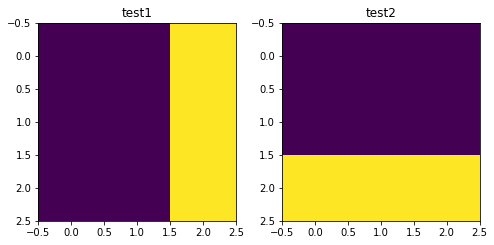

In [14]:
#collapse-hide
figure = plt.figure(figsize=(8., 8.))
plt.rcParams['figure.facecolor'] = 'white'

plt.subplot(221)
plt.imshow(test1)
plt.gca().set_title('test1')

plt.subplot(222)
plt.imshow(test2)
plt.gca().set_title('test2')

plt.show()

## Conclusion
---
We now finally understand how image classification works with such a simple example. There must be question like, where are those complex CNNs? Why not use them directly? — The above mentioned operations are the building blocks of the neural network architectures. Note this is not directly correlated to neural networks, but it does give an intuition of how things work. The discussed technique is simply passing processed matrices to a function, that yields score. 

Neural Networks contain "neurons" stacked together to form "layers". Generally, several neural network architecture has large number of layers connected to each other with operations. These "neurons" are simply function that performs operations and fire result to neurons of other layers. The "classify_img" function can be considered as a single neuron that takes input as 3x3 image array and returns the score. Based on the score we understand which class does the image falls in. A single neuron looks like the figure(3). Then stacking them all together into layers yield a neural network architecture as figure(4).


![](https://github.com/pr2tik1/blog/blob/master/_notebooks/images/nn.jpg?raw=1 "Figure(3)")
![](https://github.com/pr2tik1/blog/blob/master/_notebooks/images/nn_full.png?raw=1 "Figure(4)")

Next step would be exploring how a multi-layered perceptron or a simple neural network with, input-hidden-output layer, works. I have written few posts shared below in references.

This was my attempt to explain image classification with simplest example. Note my intent was to make reader understand image classification and not to confuse image processing with computer vision. To draw clear line, Image processing comes under computer vision as a pre-processing or post-processiong steps. The computer vision task is wide and covers object detection, image segmentation and more complex problems. The post shows that classifying images without neural networks can be done using image processing and convolution operation.

## References and Resources to check

1. [OpenCV](https://opencv.org/releases/), [numpy](https://numpy.org), [Matplotlib](https://matplotlib.org)
2. [Neural Network from scratch](https://pub.towardsai.net/neural-networks-from-scratch-a-brief-introduction-for-beginners-d3776599aaac)
3. [Why neural networks work?](https://towardsdatascience.com/exploring-neural-networks-and-their-fascinating-effectiveness-81ebc054cb16)
4. [Discussion on Image Processing and Computer Vision](https://dsp.stackexchange.com/questions/2665/a-clear-line-between-computer-vision-and-image-processing?rq=1)
5. [Digital Image Classification](https://www.e-education.psu.edu/geog480/node/496#:~:text=Digital%20image%20classification%20uses%20the,condition%20of%20the%20target%20surface.&text=There%20are%20several%20core%20principles,features%20from%20remotely%20sensed%20data.)
6. [Image Classification Slides](http://www.sc.chula.ac.th/courseware/2309507/Lecture/remote18.htm)

# Thankyou